# 0️⃣1️⃣ Six-face die: direct binary mapping

This experiment maps each die roll directly to a bit: faces **1, 2, 3** become **0**, and faces **4, 5, 6** become **1**. No extractor or rejected rolls are used, so each binary outcome costs exactly one physical roll.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

FACES = np.arange(1, 7)
BITS = np.array([0, 1])
NUM_RUNS = 10
NUM_TRIALS_PER_RUN = 10_000

DICE = {
    'Fair die': [1 / 6] * 6,
    'Minimally biased die': [0.16, 0.16, 0.16, 0.16, 0.16, 0.20],
    'Highly biased die': [0.05, 0.05, 0.10, 0.10, 0.20, 0.50],
}


In [2]:
def roll_die(weights):
    return random.choices(FACES, weights=weights, k=1)[0]


def face_to_bit(face):
    return 0 if face <= 3 else 1


def bit_probabilities(samples):
    return np.bincount(samples, minlength=2)[:2] / len(samples)


def run_experiment(weights):
    return np.array([
        bit_probabilities([face_to_bit(roll_die(weights)) for _ in range(NUM_TRIALS_PER_RUN)])
        for _ in range(NUM_RUNS)
    ])


results = {name: run_experiment(weights) for name, weights in DICE.items()}

for name, bit_runs in results.items():
    mean, std = bit_runs.mean(axis=0), bit_runs.std(axis=0)
    print(f'\n--- {name} ({NUM_RUNS} runs x {NUM_TRIALS_PER_RUN:,} trials) ---')
    print('Physical rolls per binary outcome: 1')
    print(f'0 (faces 1--3): {mean[0]:.4f} +/- {std[0]:.4f} (ideal 0.5000)')
    print(f'1 (faces 4--6): {mean[1]:.4f} +/- {std[1]:.4f} (ideal 0.5000)')



--- Fair die (10 runs x 10,000 trials) ---
Physical rolls per binary outcome: 1
0 (faces 1--3): 0.5019 +/- 0.0046 (ideal 0.5000)
1 (faces 4--6): 0.4981 +/- 0.0046 (ideal 0.5000)

--- Minimally biased die (10 runs x 10,000 trials) ---
Physical rolls per binary outcome: 1
0 (faces 1--3): 0.4796 +/- 0.0062 (ideal 0.5000)
1 (faces 4--6): 0.5204 +/- 0.0062 (ideal 0.5000)

--- Highly biased die (10 runs x 10,000 trials) ---
Physical rolls per binary outcome: 1
0 (faces 1--3): 0.2001 +/- 0.0036 (ideal 0.5000)
1 (faces 4--6): 0.7998 +/- 0.0036 (ideal 0.5000)


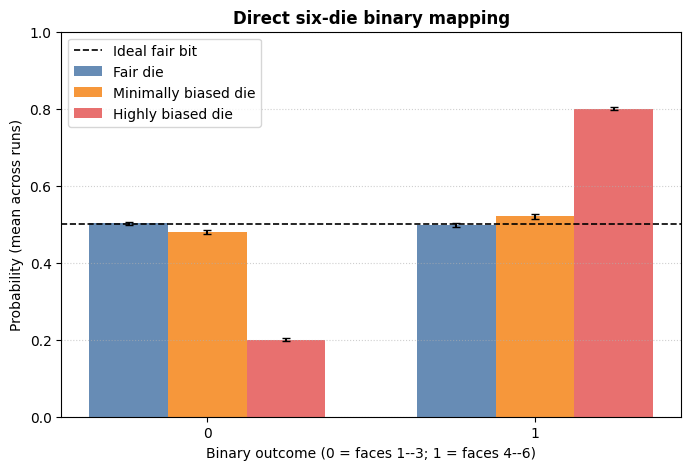

In [3]:
fig, axis = plt.subplots(figsize=(8, 5))
width = 0.24
offsets = [-width, 0, width]
colors = ['#4c78a8', '#f58518', '#e45756']

for (name, _), offset, color in zip(DICE.items(), offsets, colors):
    bit_runs = results[name]
    axis.bar(
        BITS + offset, bit_runs.mean(axis=0), width,
        yerr=bit_runs.std(axis=0), capsize=3,
        label=name, color=color, alpha=0.85,
    )

axis.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Ideal fair bit')
axis.set_title('Direct six-die binary mapping', fontweight='bold')
axis.set_xlabel('Binary outcome (0 = faces 1--3; 1 = faces 4--6)')
axis.set_ylabel('Probability (mean across runs)')
axis.set_xticks(BITS)
axis.set_ylim(0, 1)
axis.grid(axis='y', linestyle=':', alpha=0.6)
axis.legend(frameon=True)
plt.show()


Die                        Mapped-bit entropy
Fair die                            0.9999 bits
Minimally biased die                0.9987 bits
Highly biased die                   0.7222 bits


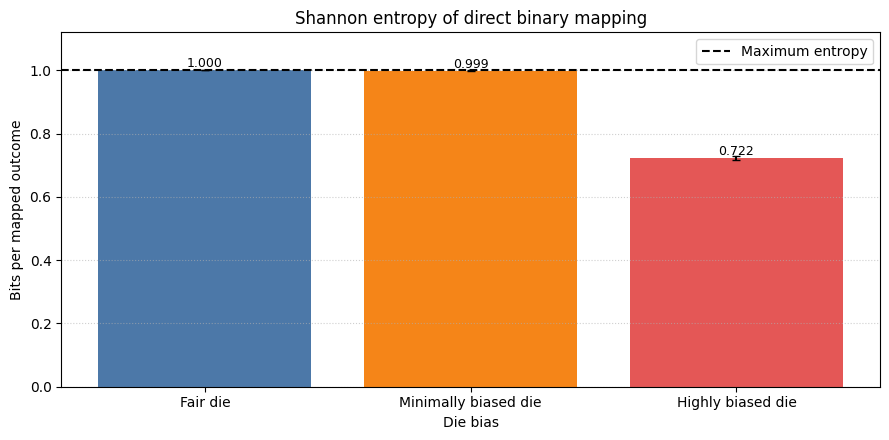

In [4]:
# This direct mapping has no extractor, so these are its raw mapped-bit entropies.
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

entropy_summary = []
for name, bit_runs in results.items():
    entropies = np.array([shannon_entropy(probabilities) for probabilities in bit_runs])
    entropy_summary.append((name, entropies.mean(), entropies.std()))

print(f"{'Die':<24} {'Mapped-bit entropy':>20}")
for name, entropy, _ in entropy_summary:
    print(f"{name:<24} {entropy:>17.4f} bits")

positions = np.arange(len(entropy_summary))
fig, axis = plt.subplots(figsize=(9, 4.5))
bars = axis.bar(positions, [row[1] for row in entropy_summary], yerr=[row[2] for row in entropy_summary], capsize=3, color=['#4c78a8', '#f58518', '#e45756'])
axis.axhline(np.log2(len(BITS)), color='black', linestyle='--', label='Maximum entropy')
axis.set(title='Shannon entropy of direct binary mapping', xlabel='Die bias', ylabel='Bits per mapped outcome', xticks=positions, xticklabels=[row[0] for row in entropy_summary], ylim=(0, 1.12))
axis.grid(axis='y', linestyle=':', alpha=0.6); axis.legend()
for bar in bars:
    axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()